# Inverse PINN for Thermal Diffusivity Identification

This notebook uses a physics-informed neural network to solve an inverse transient heat-conduction problem and identify the unknown thermal diffusivity \(\alpha\).

The governing equation is

\[\frac{\partial T}{\partial t}=\alpha\frac{\partial^2 T}{\partial x^2}.\]

Synthetic temperature observations are generated using \(\alpha_{\text{true}}=0.1\), while the PINN starts from an initial guess of \(\alpha=0.5\).

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ==== REPRODUCIBILITY ==========================================
torch.manual_seed(13)


# ==== INTERIOR COLLOCATION POINTS ==============================
n_colloc = 1000
x_colloc = torch.rand(n_colloc, 1)
x_colloc.requires_grad_(True)
t_colloc = torch.rand(n_colloc, 1)
t_colloc.requires_grad_(True)

xt_colloc = torch.cat((x_colloc, t_colloc), dim=1)


# ==== BOUNDARY POINTS =========================================
t_bc    = torch.linspace(0, 1, 100).view(-1,1)
x_left  = torch.zeros_like(t_bc)
x_right = torch.ones_like(t_bc)

xt_left  = torch.cat((x_left, t_bc), dim=1)
xt_right = torch.cat((x_right, t_bc), dim=1)


# ==== INITIAL CONDITION POINTS ================================
x_ic    = torch.linspace(0, 1, 100).view(-1,1)
t_ic    = torch.zeros_like(x_ic)
xt_ic   = torch.cat((x_ic, t_ic), dim=1)

T_ic_exact = torch.sin(torch.pi * x_ic)


# ==== NEURAL NETWORK ==========================================
model = nn.Sequential(
    nn.Linear(2, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
)


# ==== PHYSICAL PARAMETER ======================================
alpha   = nn.Parameter(torch.tensor(0.5))


# ==== OPTIMIZER ===============================================
optimizer = torch.optim.Adam(
    list(model.parameters()) + [alpha],
    lr = 0.01
)


# ==== SCHEDULER ===============================================
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.5
)

## Synthetic Measurement Data

Temperature observations are generated at randomly selected space-time locations using the known analytical solution. These data are used only as measurements for the inverse problem.

In [2]:
# ==== GENERATE DATASET ========================================
alpha_true = 0.1
alpha_history = []

x_data = torch.rand(100, 1)
t_data = torch.rand(100, 1)

T_data = (
    torch.sin(torch.pi * x_data)
    * torch.exp(-alpha_true * torch.pi**2 * t_data)
)

xt_data = torch.cat((x_data, t_data), dim=1)

## Inverse PINN Training

The network parameters and thermal diffusivity \(\alpha\) are trained simultaneously by minimizing the PDE, boundary-condition, initial-condition, and measurement-data losses.

In [3]:
# ==== RUN NN ==================================================
n_epochs = 5000

for epoch in range(n_epochs):

    # ----- PDE LOSS -------------------------------------------
    T = model(xt_colloc)

    dT_dx = torch.autograd.grad(
        T, x_colloc,
        grad_outputs=torch.ones_like(T),
        create_graph=True
    )[0]

    d2T_dx2 = torch.autograd.grad(
        dT_dx, x_colloc,
        grad_outputs=torch.ones_like(dT_dx),
        create_graph=True
    )[0]

    dT_dt = torch.autograd.grad(
        T, t_colloc,
        grad_outputs=torch.ones_like(T),
        create_graph=True
    )[0]

    pde_residual = dT_dt - alpha*d2T_dx2
    loss_pde = torch.mean(pde_residual**2)


    # ----- BOUNDARY LOSS --------------------------------------
    loss_right = torch.mean(model(xt_right)**2)
    loss_left = torch.mean(model(xt_left)**2)

    loss_bc = loss_left + loss_right


    # ----- INITIAL CONDITION LOSS -----------------------------
    T_ic = model(xt_ic)

    loss_ic = torch.mean((T_ic_exact - T_ic)**2)


    # ----- DATA LOSS ------------------------------------------
    T_pred = model(xt_data)

    loss_data = torch.mean((T_data - T_pred)**2)


    # ----- TOTAL LOSS -----------------------------------------
    loss = (loss_pde + loss_bc + loss_ic + loss_data)


    # ----- UPDATE NN + ALPHA ----------------------------------
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    alpha_history.append(alpha.item())


    # ----- MONITOR TRAINING -----------------------------------
    if epoch % 300 == 0:

        print(
            f"Epoch = {epoch:4d} | "
            f"PDE = {loss_pde.item():.6f} | "
            f"BC = {loss_bc.item():.6f} | "
            f"IC = {loss_ic.item():.6f} | "
            f"Data = {loss_data.item():.6f} | "
            f"Total = {loss.item():.6f} | "
            f"Alpha = {alpha.item():.6f}"
        )

Epoch =    0 | PDE = 0.000301 | BC = 0.008732 | IC = 0.522542 | Data = 0.228145 | Total = 0.759720 | Alpha = 0.490000
Epoch =  300 | PDE = 0.000489 | BC = 0.000061 | IC = 0.000084 | Data = 0.000037 | Total = 0.000672 | Alpha = 0.094864
Epoch =  600 | PDE = 0.000201 | BC = 0.000052 | IC = 0.000055 | Data = 0.000006 | Total = 0.000315 | Alpha = 0.097874
Epoch =  900 | PDE = 0.000405 | BC = 0.002648 | IC = 0.001681 | Data = 0.001299 | Total = 0.006033 | Alpha = 0.098775
Epoch = 1200 | PDE = 0.000093 | BC = 0.000015 | IC = 0.000004 | Data = 0.000003 | Total = 0.000114 | Alpha = 0.099167
Epoch = 1500 | PDE = 0.000066 | BC = 0.000010 | IC = 0.000002 | Data = 0.000002 | Total = 0.000080 | Alpha = 0.099432
Epoch = 1800 | PDE = 0.000048 | BC = 0.000007 | IC = 0.000002 | Data = 0.000001 | Total = 0.000058 | Alpha = 0.099591
Epoch = 2100 | PDE = 0.000037 | BC = 0.000006 | IC = 0.000002 | Data = 0.000001 | Total = 0.000046 | Alpha = 0.099683
Epoch = 2400 | PDE = 0.000032 | BC = 0.000006 | IC = 0.0

## Parameter Identification and Validation

The learned diffusivity is compared with the true value, and PINN temperature predictions are checked against the analytical solution at randomly selected points.

In [4]:
alpha_error = abs(alpha.item() - alpha_true)
alpha_rel_error = alpha_error / alpha_true * 100

print(f"True alpha       = {alpha_true:.6f}")
print(f"Learned alpha    = {alpha.item():.6f}")
print(f"Absolute error   = {alpha_error:.6e}")
print(f"Relative error   = {alpha_rel_error:.4f}%")

x_check  = torch.rand(5, 1)
t_check  = torch.rand(5, 1)
xt_check = torch.cat((x_check, t_check), dim=1)

model.eval()

with torch.no_grad():
    T_check = model(xt_check)

print("\nPINN vs analytical solution\n")
for i in range(len(xt_check)):
    x_val   = x_check[i].item()
    t_val   = t_check[i].item()
    pinn_val = T_check[i].item()
    exact_val   = (
            torch.sin(torch.pi*x_check[i])
            * torch.exp(-alpha_true*(torch.pi**2)*t_check[i])
        ).item()
    error_val = abs(pinn_val - exact_val)

    print(
            f"x = {x_val:.2f} | "
            f"t = {t_val:.2f} | "
            f"PINN = {pinn_val:.4f} | "
            f"Exact = {exact_val:.4f} | "
            f"Error = {error_val:.4f}"
        )

True alpha       = 0.100000
Learned alpha    = 0.099902
Absolute error   = 9.775758e-05
Relative error   = 0.0978%

PINN vs analytical solution

x = 0.89 | t = 0.17 | PINN = 0.2857 | Exact = 0.2860 | Error = 0.0002
x = 0.40 | t = 0.20 | PINN = 0.7811 | Exact = 0.7812 | Error = 0.0001
x = 0.99 | t = 0.93 | PINN = 0.0119 | Exact = 0.0137 | Error = 0.0018
x = 0.34 | t = 0.06 | PINN = 0.8229 | Exact = 0.8229 | Error = 0.0001
x = 0.97 | t = 0.06 | PINN = 0.0856 | Exact = 0.0866 | Error = 0.0009


## Diffusivity Convergence

The evolution of the learned thermal diffusivity during training is compared with the true value \(\alpha_{\text{true}}=0.1\).

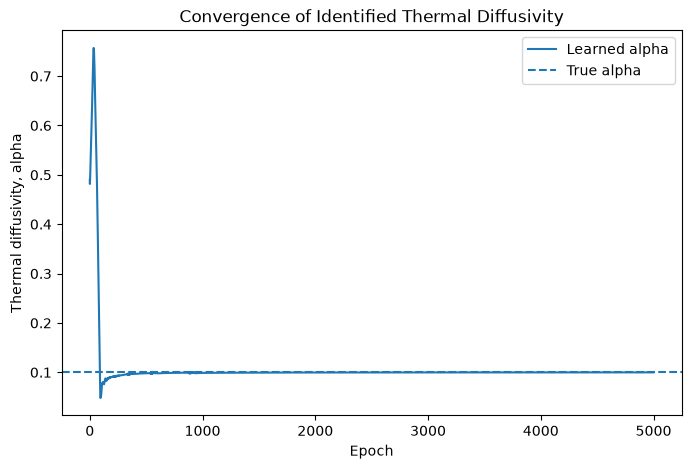

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(alpha_history, label="Learned alpha")

plt.axhline(
    y=alpha_true,
    linestyle="--",
    label="True alpha"
)

plt.xlabel("Epoch")
plt.ylabel("Thermal diffusivity, alpha")
plt.title("Convergence of Identified Thermal Diffusivity")
plt.legend()

plt.show()